## Feature Engineering and Selection

In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv', delimiter=',')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [202]:
df.drop(columns=["customerID"], inplace=True)

In [203]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors = "coerce")

In [204]:
df['AverageCharges'] = df['TotalCharges'] / (df['tenure'] + 1e-5)

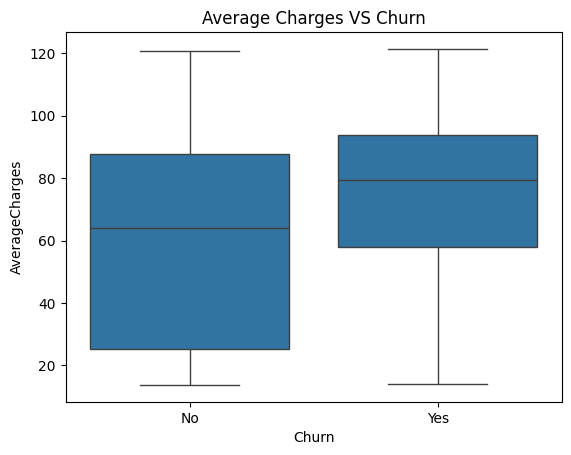

In [205]:
sns.boxplot(data=df, x="Churn", y="AverageCharges")
plt.title("Average Charges VS Churn")
plt.show()

In [206]:
df["AverageCharges"] = df["AverageCharges"].clip(
    lower=df["AverageCharges"].quantile(0.01),
    upper=df["AverageCharges"].quantile(0.99)
)

In [207]:
df["charges_per_month"] = df["TotalCharges"] / (df["tenure"] + 1e-5)

In [208]:
df.drop(columns=["gender", "PhoneService", "TotalCharges"], inplace=True)

In [209]:
labels = [0, 1, 2]
bins = [0, 12, 24, df["tenure"].max() + 1]

df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)

df['tenure_group'] = df['tenure_group'].astype(int)

In [210]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   SeniorCitizen      7043 non-null   int64  
 1   Partner            7043 non-null   str    
 2   Dependents         7043 non-null   str    
 3   tenure             7043 non-null   int64  
 4   MultipleLines      7043 non-null   str    
 5   InternetService    7043 non-null   str    
 6   OnlineSecurity     7043 non-null   str    
 7   OnlineBackup       7043 non-null   str    
 8   DeviceProtection   7043 non-null   str    
 9   TechSupport        7043 non-null   str    
 10  StreamingTV        7043 non-null   str    
 11  StreamingMovies    7043 non-null   str    
 12  Contract           7043 non-null   str    
 13  PaperlessBilling   7043 non-null   str    
 14  PaymentMethod      7043 non-null   str    
 15  MonthlyCharges     7043 non-null   float64
 16  Churn              7043 non-null   

In [211]:
df["AverageCharges"].mode()

0     17.622217
1    115.021900
Name: AverageCharges, dtype: float64

In [212]:
df["AverageCharges"] = df["AverageCharges"].fillna(df["AverageCharges"].mode()[0])

### Data Encoding

In [213]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

label_encoder = LabelEncoder()

In [214]:
df.columns

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'Churn',
       'AverageCharges', 'charges_per_month', 'tenure_group'],
      dtype='str')

In [215]:
#  Binary columns
binary_cols = ["Partner", "Dependents", "PaperlessBilling", "Churn"]

for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

multi_cols = [
    "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

In [216]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PaperlessBilling,MonthlyCharges,Churn,AverageCharges,charges_per_month,tenure_group,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,1,29.85,0,29.849702,29.849702,0,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,0,56.95,0,55.573513,55.573513,2,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,53.85,1,54.074730,54.074730,0,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,42.30,0,40.905546,40.905546,2,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,2,1,70.70,1,75.824621,75.824621,0,...,False,False,False,False,False,False,False,False,True,False


In [217]:
# Train test split
X = df.drop(columns=["Churn"])
y = df["Churn"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15)

In [218]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4930, 30), (2113, 30), (4930,), (2113,))

In [219]:
print(X_train["PaperlessBilling"].unique())
print(X_test["PaperlessBilling"].unique())

[1 0]
[0 1]


In [220]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 4930 entries, 247 to 3829
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          4930 non-null   int64  
 1   Partner                                4930 non-null   int64  
 2   Dependents                             4930 non-null   int64  
 3   tenure                                 4930 non-null   int64  
 4   PaperlessBilling                       4930 non-null   int64  
 5   MonthlyCharges                         4930 non-null   float64
 6   AverageCharges                         4930 non-null   float64
 7   charges_per_month                      4923 non-null   float64
 8   tenure_group                           4930 non-null   int64  
 9   MultipleLines_No phone service         4930 non-null   bool   
 10  MultipleLines_Yes                      4930 non-null   bool   
 11  InternetService_Fi

In [221]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,4930.0,0.163083,0.369479,0.000000,0.000000,0.000000,0.000000,1.000000
Partner,4930.0,0.482556,0.499746,0.000000,0.000000,0.000000,1.000000,1.000000
Dependents,4930.0,0.295740,0.456421,0.000000,0.000000,0.000000,1.000000,1.000000
tenure,4930.0,32.101014,24.389980,0.000000,9.000000,28.000000,55.000000,72.000000
PaperlessBilling,4930.0,0.590872,0.491723,0.000000,0.000000,1.000000,1.000000,1.000000
MonthlyCharges,4930.0,64.598245,30.048598,18.400000,35.250000,70.200000,89.600000,118.650000
AverageCharges,4930.0,64.549975,30.130649,17.622217,35.201330,70.180053,89.589717,115.021900
charges_per_month,4923.0,64.624101,30.149297,13.774931,35.408511,70.228058,89.634422,120.749161
tenure_group,4930.0,1.260243,0.882773,0.000000,0.000000,2.000000,2.000000,2.000000


In [222]:
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [223]:
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# Fill NaN values with median (or mean/most_frequent)
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train_scaled)

# Now run SMOTE
smote = SMOTE(random_state=15)
X_train_res, y_train_res = smote.fit_resample(X_train_imputed, y_train)


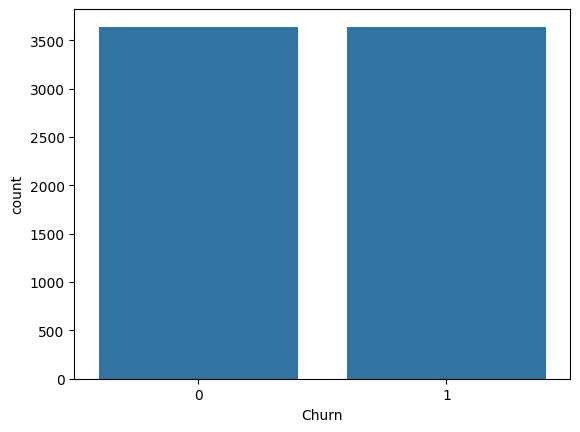

In [224]:
sns.countplot(data = df , x =y_train_res )
plt.show()

In [225]:
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Create pipeline with imputer -> smote -> model
model_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote', SMOTE(random_state=15)),
    ('classifier', RandomForestClassifier())
])

model_pipeline.fit(X_train_scaled, y_train)

# Pipeline for Logistic Regression
log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote', SMOTE(random_state=15)),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Fit the logistic model
log_pipeline.fit(X_train_scaled, y_train)

# Evaluate (Example)
print(f"RF Score: {model_pipeline.score(X_test_scaled, y_test)}")
print(f"LogReg Score: {log_pipeline.score(X_test_scaled, y_test)}")


RF Score: 0.7770941788925698
LogReg Score: 0.759110269758637


              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1534
           1       0.60      0.54      0.57       579

    accuracy                           0.78      2113
   macro avg       0.72      0.70      0.71      2113
weighted avg       0.77      0.78      0.77      2113



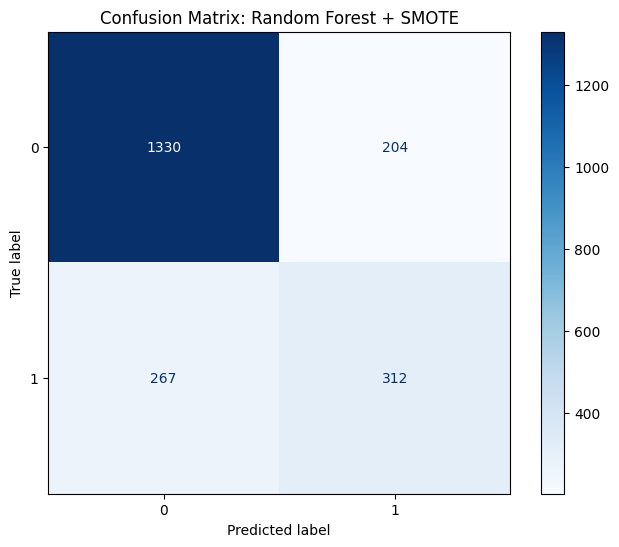

In [226]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Get predictions from the pipeline
y_pred = model_pipeline.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix: Random Forest + SMOTE')
plt.show()


              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1534
           1       0.54      0.77      0.64       579

    accuracy                           0.76      2113
   macro avg       0.72      0.76      0.73      2113
weighted avg       0.80      0.76      0.77      2113



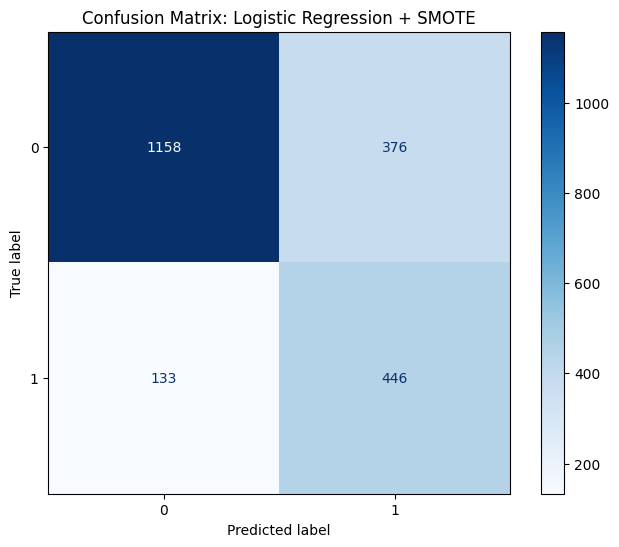

In [227]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Get predictions from the pipeline
y_pred = log_pipeline.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix: Logistic Regression + SMOTE')
plt.show()


/var/folders/69/xdlrrj6111j2zg9tbypfpx700000gn/T/ipykernel_75323/655375357.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


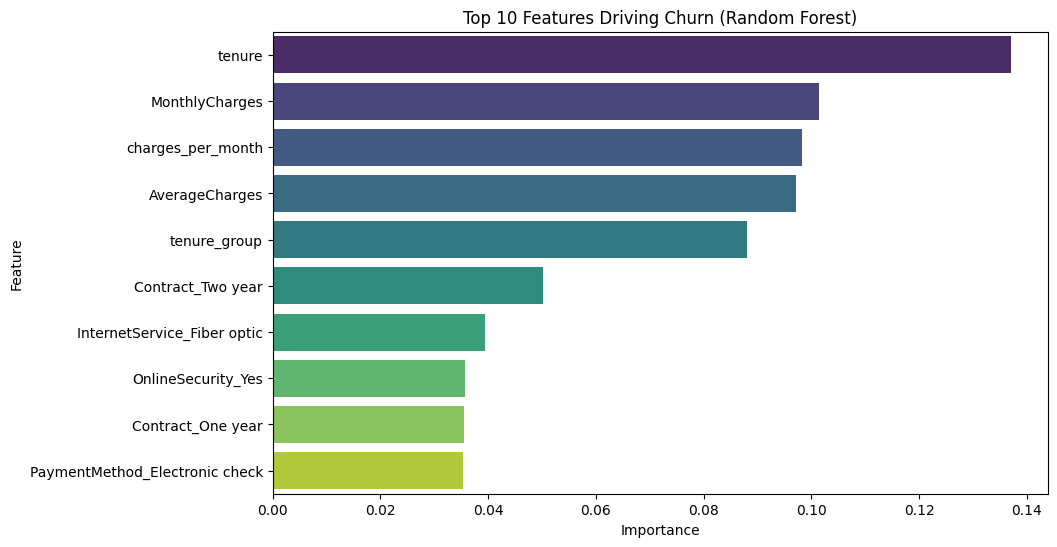

In [228]:
# Extract feature importances from the 'classifier' step
importances = model_pipeline.named_steps['classifier'].feature_importances_

# Match with feature names (assuming X_train is a DataFrame)
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the top 10
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Features Driving Churn (Random Forest)')
plt.show()

/var/folders/69/xdlrrj6111j2zg9tbypfpx700000gn/T/ipykernel_75323/1173300681.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_10_log, palette='RdBu_r')


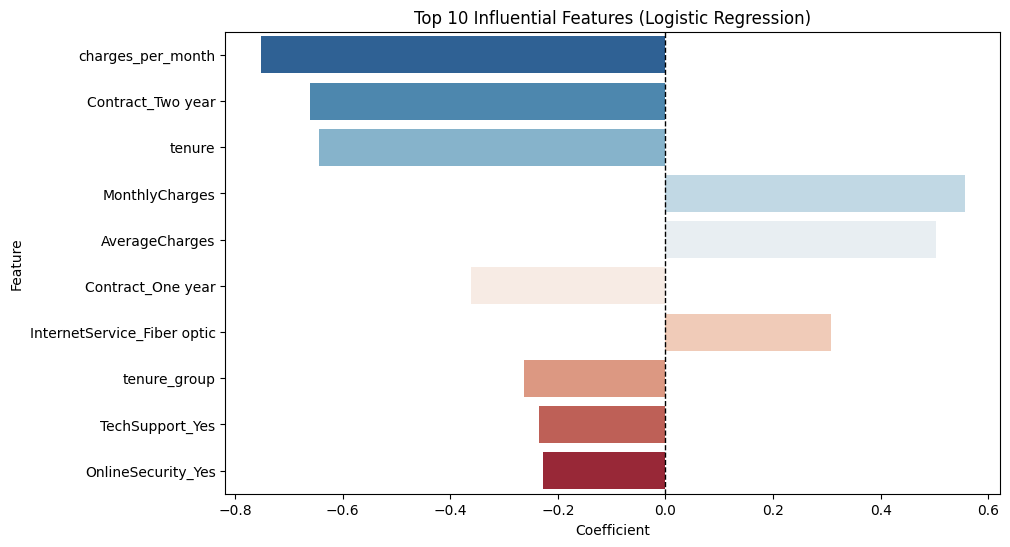

In [229]:
# Extract coefficients from the 'classifier' step of your log_pipeline
# Using .ravel() to ensure it's a 1D array
coefficients = log_pipeline.named_steps['classifier'].coef_[0]

# Match with feature names (using X_train columns)
feature_names = X_train.columns
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Calculate absolute values to find the most influential features
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
top_10_log = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
# We plot the actual Coefficient (not absolute) to show direction (positive vs negative)
sns.barplot(x='Coefficient', y='Feature', data=top_10_log, palette='RdBu_r')
plt.title('Top 10 Influential Features (Logistic Regression)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.show()

ROC-AUC: 0.8405913851377977


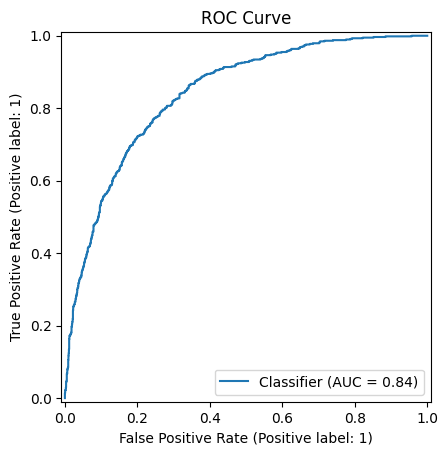

In [233]:
# ROC curve for Logistic Regression

from sklearn.metrics import RocCurveDisplay, roc_auc_score

y_prob = log_pipeline.predict_proba(X_test_scaled)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title('ROC Curve')
plt.show()

In [239]:
import joblib
import os

# Ensure the directory exists
os.makedirs("../notebooks/artifacts", exist_ok=True)

# Save the model (the classifier or the whole pipeline)
# If we want to save just the logistic model from our pipeline:
logistic_model = log_pipeline.named_steps['classifier']
joblib.dump(logistic_model, "../notebooks/artifacts/logistic_churn_model.joblib")

# Save the scaler
# If we scaler was part of a pipeline, extract it; otherwise, use the object directly
joblib.dump(scaler, "../notebooks/artifacts/scaler.joblib")

# Save the feature names (as a list or index)
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, "../notebooks/artifacts/feature_names.joblib")

# Save a config dictionary (example metadata)
config = {
    'impute_strategy': 'median',
    'random_state': 15,
    'model_type': 'Logistic Regression'
}
joblib.dump(config, "../notebooks/artifacts/preprocessing_config.joblib")

print("Artifacts saved successfully! Check the 'artifacts' directory for the saved files.")


Artifacts saved successfully! Check the 'artifacts' directory for the saved files.
